# Working with Annotated Frames

**Peak-level ground truth from TimSim synthetic timsTOF data — and how to use it for machine learning.**

TimSim writes two kinds of ground truth for every simulation:

1. **Molecule-level ground truth** — the complete molecular layout (peptides, ions,
   fragments, proteins) in `synthetic_data.db`.
2. **Peak-level annotations** — for every *peak* in a frame, which peptide / charge
   state / isotope it came from. This is what makes synthetic data useful for
   training and benchmarking ML models directly on raw signal.

This notebook is a hands-on tour of the **peak-level** side: how to build annotated
frames, read the per-peak labels, turn them into m/z–ion-mobility and m/z–retention-time
maps, understand the model-ready `to_dense_windows_with_labels` output, and feed all of
it into a small PyTorch model.

> **Prerequisites:** a TimSim simulation output directory containing a
> `synthetic_data.db`. Any DIA/DDA/midia run produces one. If you don't have one yet,
> run a quick simulation (see `CONFIGURATION.md`) or point the config cell below at an
> existing run.


## 0 · Setup

Point `DATASET_DB` at the `synthetic_data.db` of one of your TimSim runs. You can also
set the `TIMSIM_DB` environment variable instead of editing the cell.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- EDIT ME: path to a synthetic_data.db from a TimSim run --------------------
DATASET_DB = os.environ.get(
    "TIMSIM_DB",
    "/path/to/your/timsim_run/synthetic_data.db",   # <- replace with your own
)

assert os.path.exists(DATASET_DB), (
    f"synthetic_data.db not found at {DATASET_DB!r}.\n"
    "Set TIMSIM_DB or edit DATASET_DB to point at a TimSim run."
)
# Show the run name only (keeps local paths out of committed notebook output).
print("Using run:", os.path.basename(os.path.dirname(os.path.abspath(DATASET_DB))))

Using run: TIMSIM-DIA


In [2]:
from imspy_simulation.experiment import TimsTofSyntheticPrecursorFrameBuilder

# The builder reads the molecular ground truth and reconstructs frames on demand.
builder = TimsTofSyntheticPrecursorFrameBuilder(DATASET_DB)
print("Builder ready:", type(builder).__name__)

Builder ready: TimsTofSyntheticPrecursorFrameBuilder


## 1 · Enumerate precursor (MS1) frames

Annotated **precursor** frames are built one MS1 frame at a time. The `frames` table in
`synthetic_data.db` lists every frame with its `ms_type` (`0` = precursor/MS1) and
retention `time`.

In [3]:
with sqlite3.connect(DATASET_DB) as con:
    frames = pd.read_sql_query(
        "SELECT frame_id, time, ms_type FROM frames ORDER BY frame_id", con
    )

precursor_ids = frames.loc[frames.ms_type == 0, "frame_id"].astype(int).tolist()
print(f"{len(precursor_ids)} precursor frames "
      f"(of {len(frames)} total; ms_type counts: {frames.ms_type.value_counts().to_dict()})")
print("first precursor frame_ids:", precursor_ids[:8])

2135 precursor frames (of 34155 total; ms_type counts: {9: 32020, 0: 2135})
first precursor frame_ids: [1, 17, 33, 49, 65, 81, 97, 113]


## 2 · Build a single annotated frame

`build_precursor_frame_annotated(frame_id)` returns a `TimsFrameAnnotated`: the same
peaks a real MS1 frame would have, but every peak carries its ground-truth origin.

In [4]:
frame = builder.build_precursor_frame_annotated(precursor_ids[len(precursor_ids) // 2])
print(f"frame_id       = {frame.frame_id}")
print(f"retention_time = {frame.retention_time:.1f} s  ({frame.retention_time/60:.2f} min)")
print(f"num peaks      = {len(frame.mz):,}")
print(f"m/z range      = {min(frame.mz):.1f} – {max(frame.mz):.1f}")

frame_id       = 17073
retention_time = 1800.3 s  (30.00 min)
num peaks      = 10,849
m/z range      = 380.2 – 1220.6


## 3 · The `.df` view — the easy entry point

`frame.df` is a tidy per-peak table. **One row = one peak**, with its label columns:

| column | meaning |
|---|---|
| `mz`, `scan`, `inv_mobility`, `intensity`, `tof` | the peak itself |
| `peptide_id` | which peptide it belongs to (`-2` = random noise) |
| `charge_state` | charge of the contributing ion |
| `isotope_peak` | which isotope in the envelope (0 = monoisotopic) |

For most analysis and visualization, this is all you need — no windowing required.

In [5]:
df = frame.df
print("columns:", list(df.columns))
df.head(8)

columns: ['tof', 'mz', 'scan', 'inv_mobility', 'intensity', 'peptide_id', 'charge_state', 'isotope_peak']


,tof,mz,scan,inv_mobility,intensity,peptide_id,charge_state,isotope_peak
0,0,1217.611130,200,1.384250,3.813788,289,2,0
1,0,1218.113239,200,1.384250,4.585320,289,2,1
2,0,1218.614485,200,1.384250,2.674591,289,2,2
3,0,1219.116391,200,1.384250,1.079969,289,2,3
4,0,1217.611130,201,1.383172,5.720683,289,2,0
5,0,1218.113239,201,1.383172,6.877981,289,2,1
6,0,1218.614485,201,1.383172,4.011886,289,2,2
7,0,1219.116391,201,1.383172,1.619954,289,2,3


In [6]:
# label composition of this frame
n_signal = int((df.peptide_id >= 0).sum())
n_noise  = int((df.peptide_id == -2).sum())
print(f"signal peaks: {n_signal:,}   noise peaks: {n_noise:,}   "
      f"distinct peptides: {df.loc[df.peptide_id >= 0, 'peptide_id'].nunique()}")

signal peaks: 10,849   noise peaks: 0   distinct peptides: 7


## 4 · Build an m/z–ion-mobility map (with a label overlay)

The classic single-frame view: intensity as a function of **m/z** (x) and
**ion mobility / scan** (y). We build it straight from `.df` by histogramming the peaks
onto a grid. The same binning gives us an aligned **label map** (the dominant peptide id
per cell) that we can overlay.

In [7]:
def grid_peaks(mz, keys, values, labels, mz_min, mz_max, mz_bin,
               key_min, key_max, key_bin):
    """Bin peaks onto a (key-axis x m/z) grid.

    Returns (intensity_image, label_image, mz_edges, key_edges).
    - intensity accumulates (sum) per cell
    - label = the id of the highest-intensity peak in that cell (dominant contributor)
    """
    n_mz  = int(np.ceil((mz_max  - mz_min ) / mz_bin )) + 1
    n_key = int(np.ceil((key_max - key_min) / key_bin)) + 1
    col = np.round((mz   - mz_min ) / mz_bin ).astype(int)
    row = np.round((keys - key_min) / key_bin).astype(int)
    ok  = (col >= 0) & (col < n_mz) & (row >= 0) & (row < n_key)
    row, col, values, labels = row[ok], col[ok], values[ok], labels[ok]

    img = np.zeros((n_key, n_mz), np.float32)
    np.add.at(img, (row, col), values)                    # intensity accumulates

    lbl = np.full((n_key, n_mz), -1, np.int32)
    order = np.argsort(values, kind="stable")             # highest intensity wins the cell
    lbl[row[order], col[order]] = labels[order]

    mz_edges  = mz_min  + np.arange(n_mz ) * mz_bin
    key_edges = key_min + np.arange(n_key) * key_bin
    return img, lbl, mz_edges, key_edges

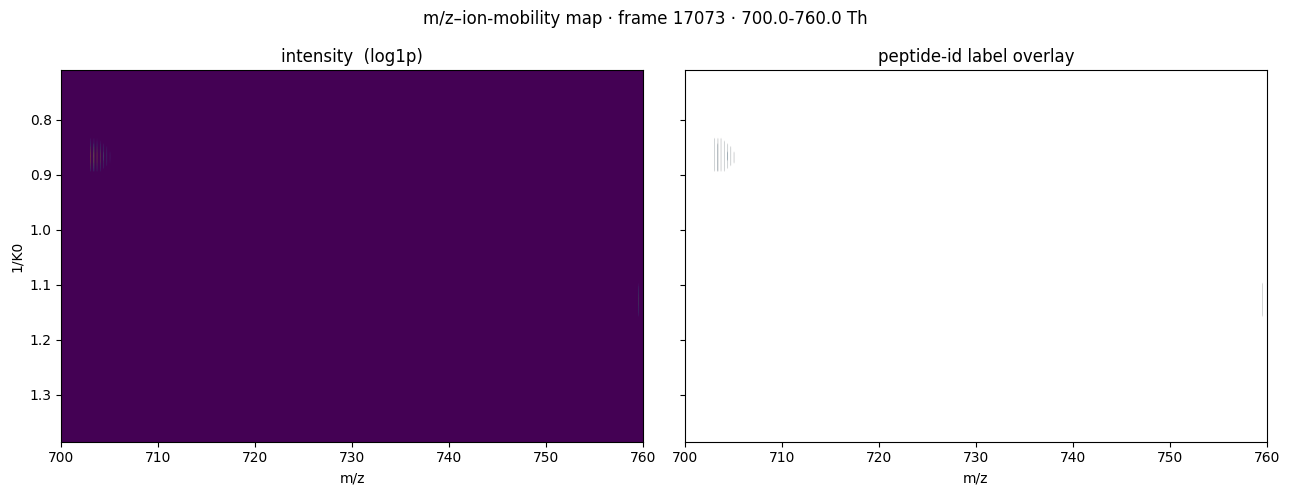

In [8]:
# Zoom to a populated m/z window so the isotope/charge structure is visible.
mz   = df.mz.to_numpy();  im = df.inv_mobility.to_numpy()
inten = df.intensity.to_numpy(); pep = df.peptide_id.to_numpy()

mz_lo, mz_hi = 700.0, 760.0
img, lbl, mz_e, im_e = grid_peaks(
    mz, im, inten, pep,
    mz_min=mz_lo, mz_max=mz_hi, mz_bin=0.02,
    key_min=im.min(), key_max=im.max(), key_bin=0.005,
)

fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
ext = [mz_e[0], mz_e[-1], im_e[-1], im_e[0]]
ax[0].imshow(np.log1p(img), aspect="auto", extent=ext, cmap="viridis")
ax[0].set_title("intensity  (log1p)"); ax[0].set_xlabel("m/z"); ax[0].set_ylabel("1/K0")
lab_show = np.where(lbl >= 0, lbl % 20, np.nan)           # mod for a repeating colour cycle
ax[1].imshow(lab_show, aspect="auto", extent=ext, cmap="tab20")
ax[1].set_title("peptide-id label overlay"); ax[1].set_xlabel("m/z")
fig.suptitle(f"m/z–ion-mobility map · frame {frame.frame_id} · {mz_lo}-{mz_hi} Th")
plt.tight_layout(); plt.show()

## 5 · `to_dense_windows_with_labels` — demystified

This is the **model-ready** representation, and its output shapes trip people up, so
here is exactly what it returns.

It slices the frame into fixed-width **windows** and returns a *stack of tiles* — **not**
a single dense image. Each tile is one ion-mobility scan restricted to one m/z window.

```
scan_idx, window_idx, mz, mobility,   X, iso_labels, charge_labels, pep_labels
   (N,)      (N,)     (N,)   (N,)   (N,Y)   (N,Y)        (N,Y)          (N,Y)
```

- **Y (columns)** is fixed = `round(window_length · 10^resolution) + 1`.
  With `window_length=10, resolution=1` that's **101 bins of 0.1 Th**.
- **N (rows)** = number of `(scan × m/z-window)` tiles that passed the
  `min_num_peaks` / `min_intensity` filter.
- The per-row 1-D arrays are metadata **for each tile**: its scan, its window key
  (negative keys are the half-shifted overlap windows), the m/z of its first peak, and
  its 1/K0.
- The `(N, Y)` arrays are per-bin: `X` = intensity, and three label planes giving the
  **dominant contributor per bin** (`-1` = empty, `-2` = noise, `≥0` = signal → isotope
  index / charge / *per-window re-indexed* peptide id 0–5).

**Why you see duplicate `scan`/`mz`/`mobility` values:** with `overlapping=True` each
m/z region is covered by two windows (aligned + half-shifted), and every scan yields one
tile per window it has peaks in. That's expected — it's a patch representation for a CNN,
not a single frame image. Use `.df` (Section 4) when you want an image; use this when you
want fixed-size labelled training patches.

In [9]:
scan_idx, win_idx, mz_w, mob_w, X, iso, chg, pep = frame.to_dense_windows_with_labels(
    window_length=10.0, resolution=1, min_num_peaks=3, min_intensity=5.0, overlapping=True,
)
print(f"N (tiles)         = {X.shape[0]}")
print(f"Y (m/z bins/tile) = {X.shape[1]}   (= round(10 * 10^1) + 1 = 101)")
print(f"per-tile metadata : scan_idx{scan_idx.shape}, win_idx{win_idx.shape}, "
      f"mz{mz_w.shape}, mobility{mob_w.shape}")
print(f"per-bin planes    : X{X.shape}, iso{iso.shape}, charge{chg.shape}, pep{pep.shape}")

N (tiles)         = 1403
Y (m/z bins/tile) = 101   (= round(10 * 10^1) + 1 = 101)
per-tile metadata : scan_idx(1403,), win_idx(1403,), mz(1403,), mobility(1403,)
per-bin planes    : X(1403, 101), iso(1403, 101), charge(1403, 101), pep(1403, 101)


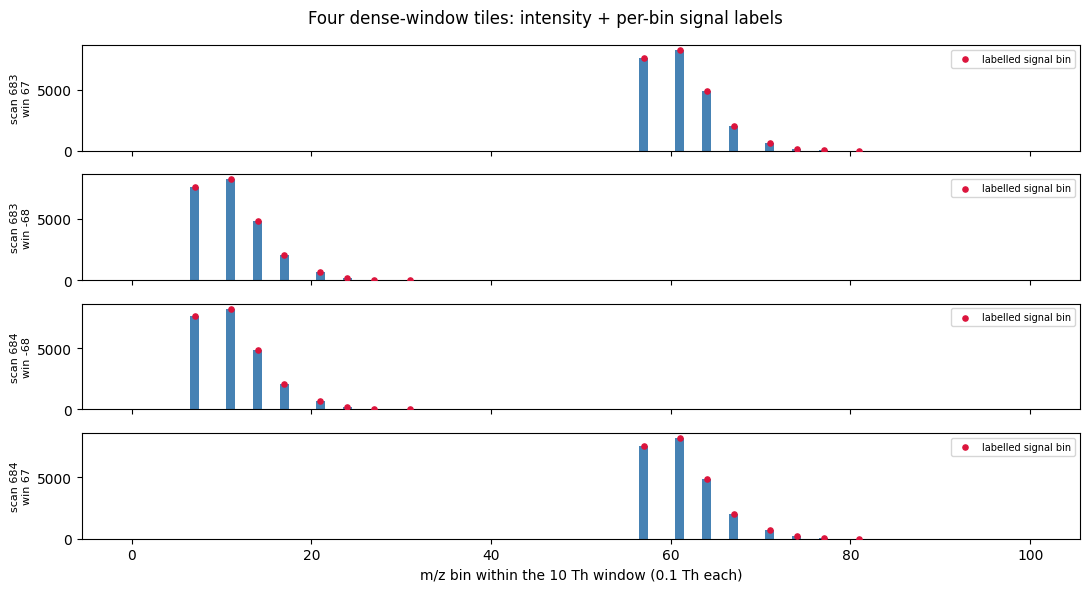

In [10]:
# Visualise a handful of tiles: intensity trace + which bins are labelled signal.
rows = np.argsort(X.sum(axis=1))[-4:][::-1]        # the 4 most intense tiles
fig, axes = plt.subplots(len(rows), 1, figsize=(11, 6), sharex=True)
bins = np.arange(X.shape[1])
for ax, r in zip(axes, rows):
    ax.bar(bins, X[r], width=1.0, color="steelblue")
    sig = np.where(pep[r] >= 0)[0]
    ax.scatter(sig, X[r][sig], color="crimson", s=14, zorder=3, label="labelled signal bin")
    ax.set_ylabel(f"scan {int(scan_idx[r])}\nwin {int(win_idx[r])}", fontsize=8)
    ax.legend(loc="upper right", fontsize=7)
axes[-1].set_xlabel("m/z bin within the 10 Th window (0.1 Th each)")
fig.suptitle("Four dense-window tiles: intensity + per-bin signal labels")
plt.tight_layout(); plt.show()

### "But I expected to build an m/z–ion-mobility image from *these*…"

You can — and doing it once makes the duplicates click. Each tile's **window key** gives its
absolute m/z offset, so `absolute_bin = window_start(win_idx) + column`. Placing every tile
cell at `(scan, absolute_bin)` rebuilds the full image. Because `overlapping=True` covers
each m/z region with two tiles, many `(scan, m/z-bin)` cells are written **twice** — those
are exactly the duplicate `scan`/`mz`/`mobility` values you noticed. Collapsing with a
max-per-cell dissolves them, and the result matches the `.df` map from Section 4.

(This is a good way to *understand* the layout; for real work, the Section-4 `.df` path is
simpler.)

6591 tile-cells -> 3352 unique (scan, m/z) pixels (3239 overlap duplicates removed)


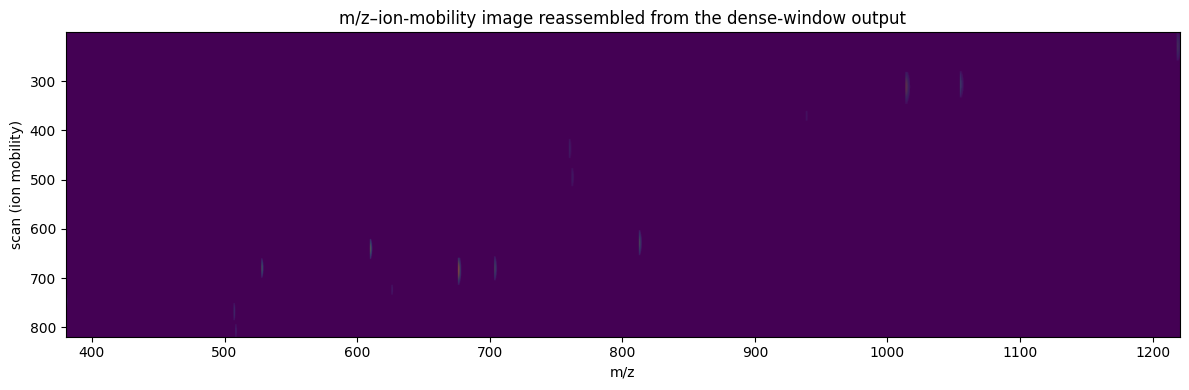

In [11]:
FACTOR = 10 ** 1                      # 10^resolution (resolution=1 above); bins are 0.1 Th

def window_start_bin(w, window_length=10.0, factor=FACTOR):
    """Absolute m/z bin index where a tile's window begins (mirrors the Rust layout)."""
    w = float(w)
    return round(w * window_length * factor) if w >= 0 \
        else round((-w * window_length - 0.5 * window_length) * factor)

rows_i, cols_c = np.nonzero(X > 0)                       # every populated tile-cell
abs_bin  = np.array([window_start_bin(win_idx[i]) for i in rows_i]) + cols_c
scan_of  = scan_idx[rows_i].astype(int)
inten_of = X[rows_i, cols_c]

b0, b1 = abs_bin.min(), abs_bin.max()
s0, s1 = scan_of.min(), scan_of.max()
img2 = np.zeros((s1 - s0 + 1, b1 - b0 + 1), np.float32)
np.maximum.at(img2, (scan_of - s0, abs_bin - b0), inten_of)   # max collapses overlap dups

n_unique = len(set(zip(scan_of.tolist(), abs_bin.tolist())))
print(f"{len(abs_bin)} tile-cells -> {n_unique} unique (scan, m/z) pixels "
      f"({len(abs_bin) - n_unique} overlap duplicates removed)")

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(np.log1p(img2), aspect="auto",
          extent=[b0 / FACTOR, b1 / FACTOR, s1, s0], cmap="viridis")
ax.set_xlabel("m/z"); ax.set_ylabel("scan (ion mobility)")
ax.set_title("m/z–ion-mobility image reassembled from the dense-window output")
plt.tight_layout(); plt.show()

## 6 · Build an m/z–retention-time map

For feature-detection-style views you want **m/z vs retention time**. There is no
built-in helper yet, so we stack frames along RT ourselves: build many precursor frames,
collapse each over the ion-mobility axis, and index the rows by `retention_time`. The
dominant-label logic gives us an aligned peptide-id map on the same grid.

In [12]:
# Sub-sample precursor frames across the gradient to keep this quick.
step = max(1, len(precursor_ids) // 150)
sample_ids = precursor_ids[::step]
frames = builder.build_precursor_frames_annotated(sample_ids, num_threads=8)
print(f"built {len(frames)} annotated frames "
      f"(RT {frames[0].retention_time/60:.1f}–{frames[-1].retention_time/60:.1f} min)")

MZ_LO, MZ_HI, MZ_BIN = 400.0, 1200.0, 0.1
mz_axis = np.arange(MZ_LO, MZ_HI + MZ_BIN, MZ_BIN)
rt      = np.array([f.retention_time for f in frames]) / 60.0     # minutes
mzrt    = np.zeros((len(frames), mz_axis.size), np.float32)
lblrt   = np.full((len(frames), mz_axis.size), -1, np.int32)

for r, f in enumerate(frames):
    d = f.df
    if len(d) == 0:
        continue
    col = np.round((d.mz.to_numpy() - MZ_LO) / MZ_BIN).astype(int)
    ok  = (col >= 0) & (col < mz_axis.size)
    col, iv, pv = col[ok], d.intensity.to_numpy()[ok], d.peptide_id.to_numpy()[ok]
    np.add.at(mzrt[r], col, iv)                       # collapse the ion-mobility axis
    o = np.argsort(iv, kind="stable")
    lblrt[r, col[o]] = pv[o]

print("m/z–RT map shape:", mzrt.shape, "(RT rows x m/z bins)")

built 153 annotated frames (RT 0.0–59.8 min)
m/z–RT map shape: (153, 8001) (RT rows x m/z bins)


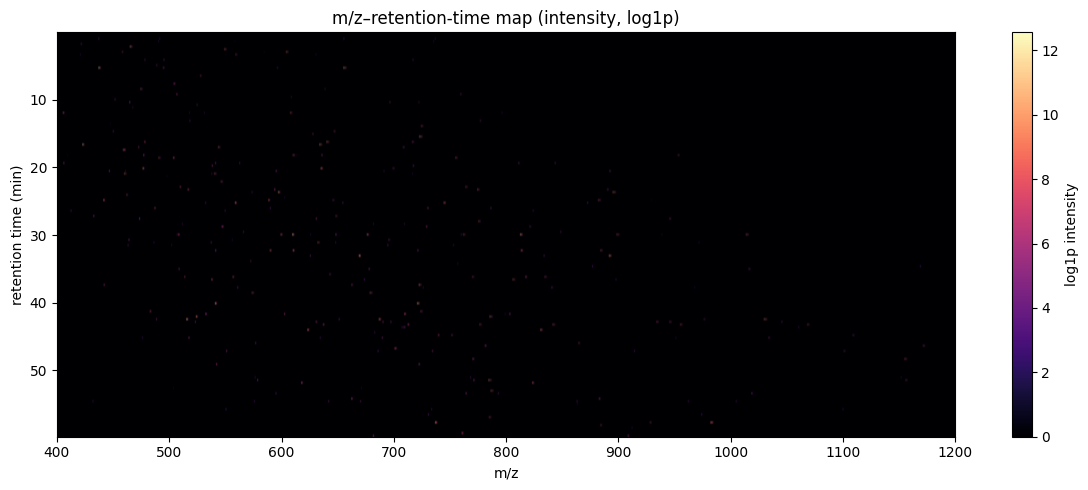

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
ext = [mz_axis[0], mz_axis[-1], rt[-1], rt[0]]
im0 = ax.imshow(np.log1p(mzrt), aspect="auto", extent=ext, cmap="magma")
ax.set_xlabel("m/z"); ax.set_ylabel("retention time (min)")
ax.set_title("m/z–retention-time map (intensity, log1p)")
fig.colorbar(im0, ax=ax, label="log1p intensity")
plt.tight_layout(); plt.show()

## 7 · Annotated fragment (MS2) frames

Everything so far used **precursor (MS1)** frames. Fragment (MS2) frames work the same
way — same `TimsFrameAnnotated`, same `.df` and `to_dense_windows_with_labels` — but you
build them through the **unified factory** `create_frame_builder(..., with_annotations=True)`,
which auto-detects a frame's type from its `ms_type` and renders precursor **or** fragment
accordingly.

A few things specific to fragment frames:

- **They only exist if fragmentation was simulated** (`apply_fragmentation = true`). Check
  that `synthetic_data.db` has `frames` with `ms_type = 9` (DIA) / the DDA MS2 type and a
  populated `fragment_ions` table.
- **DIA MS2 frames are sparse.** Each MS2 frame covers one isolation window at one RT, so
  it only contains fragments of precursors that fell in that window — **many frames are
  empty**. Below we build a batch and pick the most populated one to visualize.
- **`with_annotations=True` uses standard (eager) loading** — it holds all peptide/ion/
  fragment data in memory, so it is heavier than the precursor builder (fine here; can be
  several GB on 250k-peptide runs). It needs only the `synthetic_data.db`, not the `.d`.

> This section assumes a **DIA** dataset. For DDA, pass `AcquisitionMode.DDA`.

In [14]:
from imspy_simulation.builders import (
    create_frame_builder, AcquisitionMode, LoadingStrategy,
)

with sqlite3.connect(DATASET_DB) as con:
    ms2_ids = pd.read_sql_query(
        "SELECT frame_id FROM frames WHERE ms_type = 9 ORDER BY frame_id", con
    ).frame_id.astype(int).tolist()
    n_frag_ions = con.execute("SELECT COUNT(*) FROM fragment_ions").fetchone()[0]

print(f"{len(ms2_ids)} MS2 frames (ms_type=9); fragment_ions rows: {n_frag_ions}")
HAVE_FRAGMENTS = len(ms2_ids) > 0 and n_frag_ions > 0
if not HAVE_FRAGMENTS:
    print("No fragment data in this run — re-simulate with apply_fragmentation=true to try this section.")

32020 MS2 frames (ms_type=9); fragment_ions rows: 1094


In [15]:
if HAVE_FRAGMENTS:
    # Unified builder with annotations (standard loading required for annotations).
    frag_builder = create_frame_builder(
        db_path=DATASET_DB,
        acquisition_mode=AcquisitionMode.DIA,
        loading_strategy=LoadingStrategy.STANDARD,
        with_annotations=True,
    )
    # DIA MS2 frames are sparse — sample a mid-gradient batch and keep the busiest one.
    lo = len(ms2_ids) // 3
    sample = ms2_ids[lo:lo + 200]
    ms2_frames = frag_builder.build_frames_annotated(sample, fragment=True, num_threads=8)
    ms2_frames = sorted(ms2_frames, key=lambda f: len(f.mz), reverse=True)
    ms2 = ms2_frames[0]
    print(f"most populated sampled MS2 frame: id={ms2.frame_id}  "
          f"rt={ms2.retention_time/60:.2f} min  peaks={len(ms2.mz):,}")
    display(ms2.df.head(8))

most populated sampled MS2 frame: id=11408  rt=20.05 min  peaks=5,902


,tof,mz,scan,inv_mobility,intensity,peptide_id,charge_state,isotope_peak
0,0,147.112804,698,0.847033,3.0,442,1,0
1,0,222.096825,698,0.847033,1.0,442,3,0
2,0,244.092797,698,0.847033,2.0,442,1,0
3,0,251.107502,698,0.847033,1.0,442,3,0
4,0,296.143269,698,0.847033,1.0,442,3,0
5,0,413.538570,698,0.847033,2.0,442,3,0
6,0,413.873309,698,0.847033,1.0,442,3,1
7,0,416.176755,698,0.847033,1.0,442,3,0


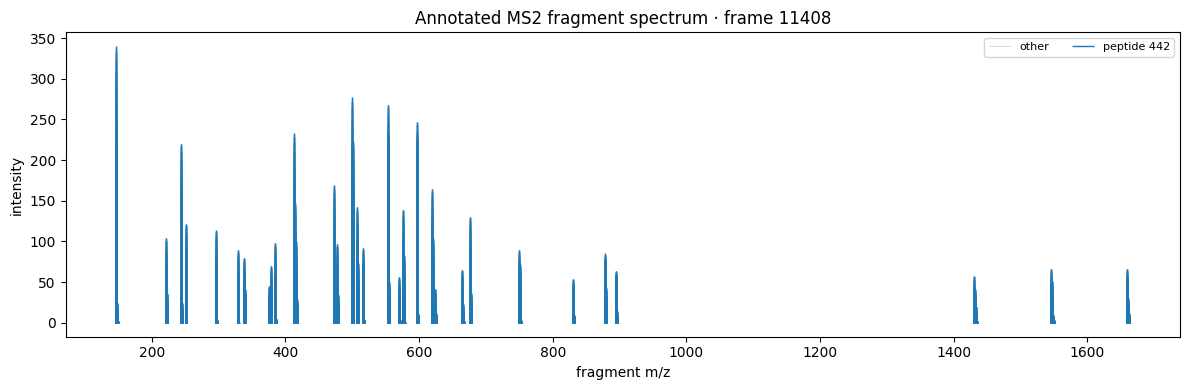

fragments per peptide (top):
            n_fragments  summed_intensity
peptide_id                               
442                5902          158377.0


In [16]:
if HAVE_FRAGMENTS and len(ms2.mz) > 0:
    d = ms2.df
    # A fragment spectrum, coloured by the peptide each fragment ion came from.
    fig, ax = plt.subplots(figsize=(12, 4))
    top_peps = d.loc[d.peptide_id >= 0, "peptide_id"].value_counts().head(6).index
    ax.vlines(d.mz, 0, d.intensity, color="lightgray", lw=0.6, label="other")
    for pid in top_peps:
        s = d[d.peptide_id == pid]
        ax.vlines(s.mz, 0, s.intensity, lw=1.0, label=f"peptide {pid}")
    ax.set_xlabel("fragment m/z"); ax.set_ylabel("intensity")
    ax.set_title(f"Annotated MS2 fragment spectrum · frame {ms2.frame_id}")
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()

    # The peak-level labels: which peptide/charge/isotope each fragment belongs to.
    print("fragments per peptide (top):")
    print(d.loc[d.peptide_id >= 0]
            .groupby("peptide_id")
            .agg(n_fragments=("mz", "size"), summed_intensity=("intensity", "sum"))
            .sort_values("summed_intensity", ascending=False).head())

## 8 · From annotations to an ML dataset

### The core tension: dense models vs. sparse spectra

Before the data prep, it is worth naming the central challenge of deep learning on raw MS
data. Most DL architectures — CNNs, vision transformers — expect **dense** tensors and
learn from populated local context. Mass spectra are the opposite: **extremely sparse**,
and ion-mobility data makes it worse, because adding the mobility axis inflates the
`(m/z × mobility)` (and, over a run, `× retention time`) volume while the number of real
peaks stays roughly the same. A naïve dense voxelization is therefore almost entirely
zeros — wasteful in memory and compute, and badly class-imbalanced (very few "signal"
pixels), which is exactly what makes training hard.

There is no single right answer; the common strategies each trade off differently, and the
annotations here support all of them:

- **Dense windowing / tiling** — carve fixed-size dense patches around populated regions
  (what `to_dense_windows_with_labels` does). Model-friendly, but you choose the window
  size and still carry some empty bins.
- **Sparse / point-cloud representations** — treat each spectrum as a list of
  `(m/z, mobility, intensity)` points and run point-cloud / set / graph models or sparse
  convolutions directly on the peaks. The per-peak `.df` **is** exactly this point cloud,
  already carrying per-point labels.
- **Hybrid** — sparse encoders that densify only locally, or attention over peaks.

The cell below quantifies the sparsity on one frame to make the tension concrete; then we
build a simple dense-windowed dataset because it plugs straight into a standard loop.

In [17]:
# How empty is a dense voxelization of a single frame?
mz_a  = df.mz.to_numpy(); scan_a = df.scan.to_numpy()
n_mz_cells   = int(np.ceil((mz_a.max() - mz_a.min()) / 0.01)) + 1      # 0.01 Th bins
n_scan_cells = int(scan_a.max() - scan_a.min()) + 1
dense_cells  = n_mz_cells * n_scan_cells
occupancy    = len(df) / dense_cells
print(f"frame {frame.frame_id}: {len(df):,} peaks in a "
      f"{n_scan_cells} x {n_mz_cells} = {dense_cells:,}-cell dense grid")
print(f"  -> occupancy {occupancy*100:.4f}%  (i.e. ~{1/occupancy:,.0f}x more empty cells "
      f"than populated ones)")

frame 17073: 10,849 peaks in a 626 x 84042 = 52,610,292-cell dense grid


  -> occupancy 0.0206%  (i.e. ~4,849x more empty cells than populated ones)


Now the dataset itself. The dense windows are already `(sample, feature)` matrices with
aligned per-bin labels — a per-bin **segmentation** target. We use **input** = the
intensity tile (log-scaled), **target** = per-bin binary mask `signal (label ≥ 0)` vs
`background`. Swap the target for `charge_labels` or `iso_labels` for a multi-class
problem. This part is framework-agnostic (pure NumPy); the optional training cell in §9
needs PyTorch.

In [18]:
def frames_to_windows(frames, **kw):
    """Concatenate dense-window tiles from many frames into one dataset."""
    Xs, Ys = [], []
    for f in frames:
        _, _, _, _, X, _, _, pep = f.to_dense_windows_with_labels(**kw)
        if X.shape[0] == 0:
            continue
        Xs.append(X.astype(np.float32))
        Ys.append((pep >= 0).astype(np.float32))        # signal vs background
    return np.concatenate(Xs), np.concatenate(Ys)

X_all, Y_all = frames_to_windows(
    frames[:60], window_length=10.0, resolution=1,
    min_num_peaks=3, min_intensity=5.0, overlapping=True,
)
X_all = np.log1p(X_all)                                  # compress dynamic range
print("dataset:", X_all.shape, "->", Y_all.shape,
      f"|  signal-bin fraction: {Y_all.mean():.3f}")

dataset: (6771, 101) -> (6771, 101) |  signal-bin fraction: 0.039


## 9 · (Optional) Train a tiny model

A minimal 1-D CNN that segments each 101-bin tile into signal / background. This is a toy
— a few epochs on CPU — meant to show that the annotations plug straight into a standard
training loop, not to be a good detector.

In [19]:
try:
    import torch
    import torch.nn as nn
    HAVE_TORCH = True
except ImportError:
    HAVE_TORCH = False
    print("PyTorch not installed — skipping the training demo (data-prep in §7 stands alone).")

In [20]:
if HAVE_TORCH:
    torch.manual_seed(0)
    Xt = torch.from_numpy(X_all)[:, None, :]             # (N, 1, 101)
    Yt = torch.from_numpy(Y_all)[:, None, :]             # (N, 1, 101)
    n_val = max(1, len(Xt) // 5)
    tr = (Xt[:-n_val], Yt[:-n_val]); va = (Xt[-n_val:], Yt[-n_val:])

    model = nn.Sequential(
        nn.Conv1d(1, 16, 5, padding=2), nn.ReLU(),
        nn.Conv1d(16, 16, 5, padding=2), nn.ReLU(),
        nn.Conv1d(16, 1, 1),
    )
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    # class imbalance: signal bins are rare -> weight the positive class
    pos_w = torch.tensor([(1 - Y_all.mean()) / max(Y_all.mean(), 1e-6)])
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    for epoch in range(15):
        model.train()
        perm = torch.randperm(len(tr[0]))
        for i in range(0, len(perm), 128):
            idx = perm[i:i + 128]
            opt.zero_grad()
            loss = loss_fn(model(tr[0][idx]), tr[1][idx])
            loss.backward(); opt.step()
        if epoch % 3 == 0 or epoch == 14:
            model.eval()
            with torch.no_grad():
                vp = (model(va[0]) > 0).float()
                acc = (vp == va[1]).float().mean().item()
                tp = ((vp == 1) & (va[1] == 1)).sum().item()
                recall = tp / max((va[1] == 1).sum().item(), 1)
            print(f"epoch {epoch:2d}  val_loss={loss_fn(model(va[0]), va[1]):.3f}  "
                  f"val_acc={acc:.3f}  signal_recall={recall:.3f}")
    print("\nTrained. The point: annotated frames -> (input, per-bin label) -> standard loop.")

epoch  0  val_loss=0.786  val_acc=0.977  signal_recall=1.000


epoch  3  val_loss=0.071  val_acc=1.000  signal_recall=1.000


epoch  6  val_loss=0.016  val_acc=1.000  signal_recall=1.000


epoch  9  val_loss=0.005  val_acc=1.000  signal_recall=1.000


epoch 12  val_loss=0.002  val_acc=1.000  signal_recall=1.000


epoch 14  val_loss=0.002  val_acc=1.000  signal_recall=1.000

Trained. The point: annotated frames -> (input, per-bin label) -> standard loop.


> **This is one illustration, not a recommendation.** The dense-window + per-bin
> segmentation above is deliberately simple — it shows *how* the annotations plug into a
> standard training loop, not that it is the best way to model this data. Better approaches
> very likely exist: sparse / point-cloud models operating directly on the raw peaks,
> attention over peak sets, multi-task heads that jointly predict charge / isotope /
> peptide, or models that use 2-D/3-D context across scans and retention time. Treat the
> per-peak labels as ground truth you can build almost any supervised task on — the
> representation and architecture are yours to choose.

## Recap & pointers

- **`frame.df`** is the easy path: per-peak `mz / scan / inv_mobility / intensity` plus
  `peptide_id / charge_state / isotope_peak`. Grid it yourself for m/z–IM or m/z–RT maps.
- **`to_dense_windows_with_labels`** is the model-ready path: a stack of `N` fixed-width
  `(scan × m/z-window)` tiles, each `Y = round(window_length·10^resolution)+1` bins, with
  aligned per-bin label planes. Duplicate per-tile metadata is expected with
  `overlapping=True`.
- **Fragment (MS2) frames** come from the unified `create_frame_builder(...,
  with_annotations=True)` and behave identically to precursor frames (same
  `TimsFrameAnnotated`). They require `apply_fragmentation=true` at simulation time and use
  heavier eager loading. In DIA, MS2 frames are sparse — sample and keep the populated ones.
- **Molecule-level** ground truth lives in `synthetic_data.db` (tables `peptides`, `ions`,
  `fragment_ions`, …) if you need to join labels back to sequences.

See `CONFIGURATION.md` for the full config reference and the annotated-API summary.
